# Plain NW and Tukey Robust NW with Outliers

This notebook reproduces the selected group-10 comparison for

$$u=\sin(x+y)+\varepsilon$$

using 150 samples, 5% Gaussian response noise, and 10 response outliers. The active direction is fixed at the analytical value $\theta/\pi=0.25$.


## 1. Imports and project paths

Load the numerical and plotting libraries together with the local SI-DL implementation used for the Gaussian Nadaraya–Watson estimate.


In [10]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUT_DIR = Path.cwd()
CSV_DIR = OUTPUT_DIR / "csv"
PROJECT_ROOT = OUTPUT_DIR.parents[1]
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

si_dl_path = PROJECT_ROOT / "SI-DL-main"
if str(si_dl_path) not in sys.path:
    sys.path.insert(0, str(si_dl_path))

import SI_DL


## 2. Experiment settings

The settings match the original group-10 result. Outliers are added only to the response, with random signed amplitudes between 1 and 4.


In [11]:
RANDOM_STATE = 4209
N_SAMPLES = 150
N_OUTLIERS = 10
NOISE_PERCENT = 5
OUTLIER_DELTA_MIN = 1.0
OUTLIER_DELTA_MAX = 4.0

THETA = np.pi / 4.0
THETA_OVER_PI = THETA / np.pi
BANDWIDTH = 0.1
TUKEY_C = 4.685
TUKEY_ITERATIONS = 5
N_THETA = 241

SAMPLES_CSV = CSV_DIR / "samples.csv"
OUTLIERS_CSV = CSV_DIR / "outliers.csv"
FIT_CSV = CSV_DIR / "fit.csv"
THETA_SCAN_CSV = CSV_DIR / "theta_scan.csv"
BEST_THETA_CSV = CSV_DIR / "best_theta.csv"
PLOT_PATH = OUTPUT_DIR / "outliers.png"

CSV_DIR.mkdir(parents=True, exist_ok=True)


## 3. Generate noisy data and response outliers

Draw $x$ and $y$ independently on $[0,5]$. Gaussian noise is scaled to 5% of the clean-response standard deviation. Ten distinct observations then receive an additional signed response shift.


In [12]:
rng = np.random.default_rng(RANDOM_STATE)
x = rng.uniform(0.0, 5.0, size=N_SAMPLES)
y = rng.uniform(0.0, 5.0, size=N_SAMPLES)
u_clean = np.sin(x + y)

noise_scale = (NOISE_PERCENT / 100.0) * np.std(u_clean, ddof=0)
noise = rng.normal(0.0, noise_scale, size=N_SAMPLES)
u_noisy = u_clean + noise
u_observed = u_noisy.copy()

outlier_indices = rng.choice(N_SAMPLES, size=N_OUTLIERS, replace=False)
outlier_shifts = (
    rng.choice([-1.0, 1.0], size=N_OUTLIERS)
    * rng.uniform(OUTLIER_DELTA_MIN, OUTLIER_DELTA_MAX, size=N_OUTLIERS)
)
u_observed[outlier_indices] += outlier_shifts

is_outlier = np.zeros(N_SAMPLES, dtype=bool)
is_outlier[outlier_indices] = True

samples = pd.DataFrame({
    "sample_index": np.arange(N_SAMPLES),
    "x": x,
    "y": y,
    "u_clean": u_clean,
    "noise": noise,
    "u_noisy": u_noisy,
    "u_observed": u_observed,
    "is_outlier": is_outlier,
})
samples.to_csv(SAMPLES_CSV, index=False)

outliers = samples.loc[is_outlier].copy()
outliers["response_shift"] = outliers["u_observed"] - outliers["u_noisy"]
outliers = outliers.sort_values("sample_index").reset_index(drop=True)
outliers.to_csv(OUTLIERS_CSV, index=False)

print(f"Generated {N_SAMPLES} observations with {is_outlier.sum()} outliers.")


Generated 150 observations with 10 outliers.


## 4. Project onto the active coordinate

At the known direction $\theta=\pi/4$, the one-dimensional coordinate is

$$\Pi_\theta=\cos(\theta)x+\sin(\theta)y.$$


In [13]:
coordinate = np.cos(THETA) * x + np.sin(THETA) * y
coordinate_order = np.argsort(coordinate)

print(f"theta/pi = {THETA_OVER_PI:.2f}")
print(f"coordinate range = [{coordinate.min():.3f}, {coordinate.max():.3f}]")


theta/pi = 0.25
coordinate range = [0.502, 6.862]


## 5. Plain Gaussian NW mean

Compute the leave-one-out Nadaraya–Watson conditional mean with the fixed bandwidth used in the original experiment.


In [14]:
plain_mean = SI_DL.gaussian_kernel_conditional_mean(
    coordinate,
    u_observed,
    bandwidth=BANDWIDTH,
    standardize=True,
    leave_one_out=True,
    boundary="mirror",
)


## 6. Tukey robust NW mean

Start from the same Gaussian kernel weights. At each target observation, update the local mean five times using Tukey biweight residual weights. Large residuals receive zero weight, reducing the influence of the ten contaminated responses.


In [15]:
coordinate_scale = float(np.std(coordinate, ddof=0))
standardized_coordinate = (coordinate - np.mean(coordinate)) / coordinate_scale
distances = np.abs(
    standardized_coordinate[:, None] - standardized_coordinate[None, :]
)
kernel_weights = np.exp(-0.5 * (distances / BANDWIDTH) ** 2)
np.fill_diagonal(kernel_weights, 0.0)

global_mad = 1.4826 * np.median(np.abs(u_observed - np.median(u_observed)))
minimum_scale = max(global_mad * 0.05, np.finfo(float).eps)
tukey_mean = np.empty_like(u_observed, dtype=float)

for row_index in range(N_SAMPLES):
    local_weights = kernel_weights[row_index].copy()
    if np.sum(local_weights) <= np.finfo(float).eps:
        nearest = np.argsort(distances[row_index])[1:9]
        local_weights[nearest] = 1.0

    local_mean = float(np.sum(local_weights * u_observed) / np.sum(local_weights))

    for _ in range(TUKEY_ITERATIONS):
        absolute_residual = np.abs(u_observed - local_mean)
        valid = (
            np.isfinite(absolute_residual)
            & np.isfinite(local_weights)
            & (local_weights > 0.0)
        )

        if np.any(valid):
            sorted_index = np.argsort(absolute_residual[valid])
            sorted_residual = absolute_residual[valid][sorted_index]
            sorted_weights = local_weights[valid][sorted_index]
            cumulative_weight = np.cumsum(sorted_weights)
            median_position = np.searchsorted(
                cumulative_weight,
                0.5 * cumulative_weight[-1],
                side="left",
            )
            weighted_median_residual = float(sorted_residual[median_position])
        else:
            weighted_median_residual = float(np.median(absolute_residual))

        local_scale = max(1.4826 * weighted_median_residual, minimum_scale)
        standardized_residual = (u_observed - local_mean) / (TUKEY_C * local_scale)
        robust_weights = np.zeros_like(local_weights)
        retained = np.abs(standardized_residual) < 1.0
        robust_weights[retained] = (1.0 - standardized_residual[retained] ** 2) ** 2

        combined_weights = local_weights * robust_weights
        combined_sum = float(np.sum(combined_weights))
        if combined_sum <= np.finfo(float).eps:
            break

        updated_mean = float(np.sum(combined_weights * u_observed) / combined_sum)
        if abs(updated_mean - local_mean) <= 1.0e-10:
            local_mean = updated_mean
            break
        local_mean = updated_mean

    tukey_mean[row_index] = local_mean


## 7. Save the fit data

The compact fit table contains the projected coordinate, observed response, outlier flag, and both conditional-mean estimates.


In [16]:
fit = pd.DataFrame({
    "sample_index": np.arange(N_SAMPLES),
    "coordinate": coordinate,
    "u_observed": u_observed,
    "is_outlier": is_outlier,
    "plain_nw_mean": plain_mean,
    "tukey_nw_mean": tukey_mean,
    "theta_over_pi": THETA_OVER_PI,
    "bandwidth": BANDWIDTH,
})
fit.to_csv(FIT_CSV, index=False)
fit.head()


,sample_index,coordinate,u_observed,is_outlier,plain_nw_mean,tukey_nw_mean,theta_over_pi,bandwidth
0,0,1.146197,1.053389,False,0.985122,0.987801,0.25,0.1
1,1,2.924406,-0.875167,False,-0.703780,-0.828943,0.25,0.1
2,2,2.189546,0.024449,False,0.046523,0.010364,0.25,0.1
3,3,1.788998,0.576167,False,0.987302,0.483292,0.25,0.1
4,4,2.707438,-0.687813,False,-0.529553,-0.621698,0.25,0.1


## 8. Find the best direction

Scan 241 candidate directions from $0$ to $\pi$. Plain SI-DL uses the ordinary NW conditional mean. Robust SI-DL uses the Tukey NW conditional mean and a second Tukey weighting step when computing the covariance score.

For both methods, the objective is $1-S_{cov}$; therefore, the best direction is the angle with the smallest objective value.


In [17]:
theta_values = np.linspace(0.0, np.pi, N_THETA)
theta_scan_records = []

for candidate_theta in theta_values:
    candidate_coordinate = (
        np.cos(candidate_theta) * x + np.sin(candidate_theta) * y
    )

    # Plain SI-DL score from the ordinary NW conditional mean.
    plain_score = SI_DL.explained_variance_score(
        candidate_coordinate,
        u_observed,
        bandwidth=BANDWIDTH,
    )
    plain_objective = float(1.0 - plain_score["S_cov"])

    # Tukey robust NW conditional mean at the same candidate direction.
    candidate_scale = float(np.std(candidate_coordinate, ddof=0))
    candidate_standardized = (
        candidate_coordinate - np.mean(candidate_coordinate)
    ) / candidate_scale
    candidate_distances = np.abs(
        candidate_standardized[:, None] - candidate_standardized[None, :]
    )
    candidate_kernel = np.exp(
        -0.5 * (candidate_distances / BANDWIDTH) ** 2
    )
    np.fill_diagonal(candidate_kernel, 0.0)

    candidate_global_mad = 1.4826 * np.median(
        np.abs(u_observed - np.median(u_observed))
    )
    candidate_minimum_scale = max(
        candidate_global_mad * 0.05,
        np.finfo(float).eps,
    )
    candidate_robust_mean = np.empty_like(u_observed, dtype=float)

    for row_index in range(N_SAMPLES):
        local_weights = candidate_kernel[row_index].copy()
        if np.sum(local_weights) <= np.finfo(float).eps:
            nearest = np.argsort(candidate_distances[row_index])[1:9]
            local_weights[nearest] = 1.0

        local_mean = float(
            np.sum(local_weights * u_observed) / np.sum(local_weights)
        )

        for _ in range(TUKEY_ITERATIONS):
            absolute_residual = np.abs(u_observed - local_mean)
            valid = (
                np.isfinite(absolute_residual)
                & np.isfinite(local_weights)
                & (local_weights > 0.0)
            )

            if np.any(valid):
                sorted_index = np.argsort(absolute_residual[valid])
                sorted_residual = absolute_residual[valid][sorted_index]
                sorted_weights = local_weights[valid][sorted_index]
                cumulative_weight = np.cumsum(sorted_weights)
                median_position = np.searchsorted(
                    cumulative_weight,
                    0.5 * cumulative_weight[-1],
                    side="left",
                )
                weighted_median_residual = float(
                    sorted_residual[median_position]
                )
            else:
                weighted_median_residual = float(
                    np.median(absolute_residual)
                )

            local_scale = max(
                1.4826 * weighted_median_residual,
                candidate_minimum_scale,
            )
            standardized_residual = (
                u_observed - local_mean
            ) / (TUKEY_C * local_scale)
            robust_local_weights = np.zeros_like(local_weights)
            retained = np.abs(standardized_residual) < 1.0
            robust_local_weights[retained] = (
                1.0 - standardized_residual[retained] ** 2
            ) ** 2

            combined_weights = local_weights * robust_local_weights
            combined_sum = float(np.sum(combined_weights))
            if combined_sum <= np.finfo(float).eps:
                break

            updated_mean = float(
                np.sum(combined_weights * u_observed) / combined_sum
            )
            if abs(updated_mean - local_mean) <= 1.0e-10:
                local_mean = updated_mean
                break
            local_mean = updated_mean

        candidate_robust_mean[row_index] = local_mean

    # Integrate Tukey residual weights into the robust SI-DL score.
    robust_residual = u_observed - candidate_robust_mean
    residual_center = float(np.median(robust_residual))
    residual_scale = 1.4826 * float(
        np.median(np.abs(robust_residual - residual_center))
    )
    residual_scale = max(residual_scale, np.finfo(float).eps)
    standardized_global_residual = (
        robust_residual - residual_center
    ) / (TUKEY_C * residual_scale)
    score_weights = np.zeros(N_SAMPLES, dtype=float)
    score_retained = np.abs(standardized_global_residual) < 1.0
    score_weights[score_retained] = (
        1.0 - standardized_global_residual[score_retained] ** 2
    ) ** 2

    weight_sum = float(np.sum(score_weights))
    weighted_response_mean = float(
        np.sum(score_weights * u_observed) / weight_sum
    )
    weighted_fit_mean = float(
        np.sum(score_weights * candidate_robust_mean) / weight_sum
    )
    response_centered = u_observed - weighted_response_mean
    fit_centered = candidate_robust_mean - weighted_fit_mean
    weighted_variance = float(
        np.sum(score_weights * response_centered**2) / weight_sum
    )
    weighted_covariance = float(
        np.sum(score_weights * response_centered * fit_centered) / weight_sum
    )
    robust_score_raw = weighted_covariance / weighted_variance
    robust_score = float(np.clip(robust_score_raw, 0.0, 1.0))
    robust_objective = float(1.0 - robust_score)
    effective_n = float(
        weight_sum**2 / np.sum(score_weights**2)
    )

    theta_scan_records.extend([
        {
            "method": "SI-DL",
            "theta": candidate_theta,
            "theta_over_pi": candidate_theta / np.pi,
            "score": float(plain_score["S_cov"]),
            "objective_error": plain_objective,
            "effective_n": N_SAMPLES,
        },
        {
            "method": "Robust SI-DL",
            "theta": candidate_theta,
            "theta_over_pi": candidate_theta / np.pi,
            "score": robust_score,
            "objective_error": robust_objective,
            "effective_n": effective_n,
        },
    ])

theta_scan = pd.DataFrame(theta_scan_records)
theta_scan.to_csv(THETA_SCAN_CSV, index=False)
print(f"Scanned {N_THETA} candidate directions for both methods.")


Scanned 241 candidate directions for both methods.


## 9. Compare the best directions

The table reports each method's best direction and its distance from the analytical value 0.25. The final row quantifies the change produced by robust weighting.


In [18]:
best_records = []

for method, group in theta_scan.groupby("method", sort=False):
    best_row = group.loc[group["objective_error"].idxmin()]
    best_records.append({
        "method": method,
        "best_theta": float(best_row["theta"]),
        "best_theta_over_pi": float(best_row["theta_over_pi"]),
        "theta_abs_error": abs(
            float(best_row["theta_over_pi"]) - THETA_OVER_PI
        ),
        "minimum_objective_error": float(best_row["objective_error"]),
        "best_score": float(best_row["score"]),
        "effective_n": float(best_row["effective_n"]),
    })

best_theta = pd.DataFrame(best_records)
plain_best = best_theta.loc[best_theta["method"].eq("SI-DL")].iloc[0]
robust_best = best_theta.loc[
    best_theta["method"].eq("Robust SI-DL")
].iloc[0]

impact = pd.DataFrame([{
    "method": "Robust impact",
    "best_theta": np.nan,
    "best_theta_over_pi": (
        robust_best["best_theta_over_pi"]
        - plain_best["best_theta_over_pi"]
    ),
    "theta_abs_error": (
        robust_best["theta_abs_error"]
        - plain_best["theta_abs_error"]
    ),
    "minimum_objective_error": (
        robust_best["minimum_objective_error"]
        - plain_best["minimum_objective_error"]
    ),
    "best_score": robust_best["best_score"] - plain_best["best_score"],
    "effective_n": robust_best["effective_n"] - plain_best["effective_n"],
}])

best_theta_report = pd.concat([best_theta, impact], ignore_index=True)
best_theta_report.to_csv(BEST_THETA_CSV, index=False)
best_theta_report


,method,best_theta,best_theta_over_pi,theta_abs_error,minimum_objective_error,best_score,effective_n
0,SI-DL,0.850848,0.270833,0.020833,0.476184,0.523816,150.00000
1,Robust SI-DL,0.785398,0.250000,0.000000,0.019310,0.980690,135.82711
2,Robust impact,NaN,-0.020833,-0.020833,-0.456874,0.456874,-14.17289


## 10. Plot the selected comparison

The original group-10 comparison remains the only retained figure.


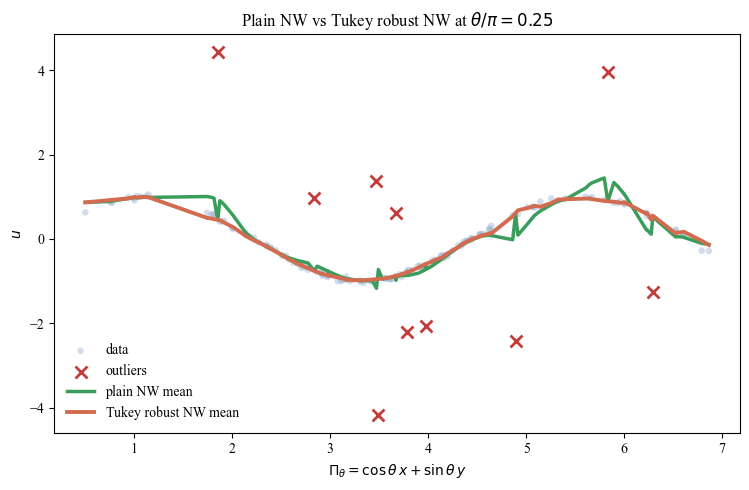

Saved outliers.png


In [19]:
fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.scatter(
    coordinate[~is_outlier],
    u_observed[~is_outlier],
    s=22,
    color="#9db3d1",
    alpha=0.45,
    edgecolors="none",
    label="data",
)
ax.scatter(
    coordinate[is_outlier],
    u_observed[is_outlier],
    s=74,
    color="#c43c39",
    marker="x",
    linewidths=2.0,
    label="outliers",
)
ax.plot(
    coordinate[coordinate_order],
    plain_mean[coordinate_order],
    color="#3a9d5c",
    linewidth=2.5,
    label="plain NW mean",
)
ax.plot(
    coordinate[coordinate_order],
    tukey_mean[coordinate_order],
    color="#d26b4f",
    linewidth=2.8,
    label="Tukey robust NW mean",
)
ax.set_xlabel(r"$\Pi_\theta=\cos\theta\,x+\sin\theta\,y$")
ax.set_ylabel(r"$u$")
ax.set_title(rf"Plain NW vs Tukey robust NW at $\theta/\pi={THETA_OVER_PI:.2f}$")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=240)
plt.show()

print(f"Saved {PLOT_PATH.name}")


## 11. Output files

The directory contains one notebook, one figure, and five concise CSV files.


In [20]:
pd.DataFrame({
    "file": [
        str(SAMPLES_CSV.relative_to(OUTPUT_DIR)),
        str(OUTLIERS_CSV.relative_to(OUTPUT_DIR)),
        str(FIT_CSV.relative_to(OUTPUT_DIR)),
        str(THETA_SCAN_CSV.relative_to(OUTPUT_DIR)),
        str(BEST_THETA_CSV.relative_to(OUTPUT_DIR)),
        PLOT_PATH.name,
    ],
    "description": [
        "Generated noisy observations",
        "The ten response outliers",
        "Plain and robust NW estimates",
        "SI-DL and robust SI-DL angle scan",
        "Best directions and robust impact",
        "Selected comparison figure",
    ],
})


,file,description
0,csv/samples.csv,Generated noisy observations
1,csv/outliers.csv,The ten response outliers
2,csv/fit.csv,Plain and robust NW estimates
3,csv/theta_scan.csv,SI-DL and robust SI-DL angle scan
4,csv/best_theta.csv,Best directions and robust impact
5,outliers.png,Selected comparison figure
